In [3]:
import numpy as np 
# import sklearn as sk
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

In [4]:
def pmatrix(a, digit : int =3, T : bool =False):
    """Returns a LaTeX bmatrix
    :a: numpy array
    :returns: LaTeX bmatrix as a string
    """
    if len(a.shape) > 2:
        raise ValueError('bmatrix can at most display two dimensions')
    lines = str(np.round(a, digit)).replace('[', '').replace(']', '').splitlines()
    rv = [r'\begin{pmatrix}']
    if not T:
        rv += ['  ' + ' & '.join(l.split()) + r'\\' for l in lines]
    else:
        rv += ['  ' + '\\\\ '.join(l.split()) for l in lines]
    rv +=  [r'\end{pmatrix}']
    return '\n'.join(rv)

In [41]:
# Данные для x1, x2, y из Таблицы 1
x1 = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.8, 1.0])
x2 = np.array([-0.6, -0.8, 0.2, -1.0, -0.4, 1.0, 0.6, -0.2, 0.0, 0.4])
y = np.array([-6.805, -7.433, -2.070, -7.106, -3.465, -3.103, -2.177, -1.333, 0.091, -0.282])

# Данные для y_pi из второй таблицы
y_pi = np.array([
    -1.085, -0.833, -0.830, -0.866, -1.065, -1.103, -1.017, -1.333, -1.149, -0.762,
    -1.113, -0.738, -1.342, -0.892, -0.552, -1.183, -1.193, -1.214, -1.043, -0.686
])

In [42]:
F = np.array([[1 for _ in range(10)],
    x1, 
    x2, 
    x1**2,
    x1*x2,
    x2**2
])

In [7]:
F.T # Матрица регрессоров

array([[ 1.  , -1.  , -0.6 ,  1.  ,  0.6 ,  0.36],
       [ 1.  , -0.8 , -0.8 ,  0.64,  0.64,  0.64],
       [ 1.  , -0.6 ,  0.2 ,  0.36, -0.12,  0.04],
       [ 1.  , -0.4 , -1.  ,  0.16,  0.4 ,  1.  ],
       [ 1.  , -0.2 , -0.4 ,  0.04,  0.08,  0.16],
       [ 1.  ,  0.  ,  1.  ,  0.  ,  0.  ,  1.  ],
       [ 1.  ,  0.2 ,  0.6 ,  0.04,  0.12,  0.36],
       [ 1.  ,  0.4 , -0.2 ,  0.16, -0.08,  0.04],
       [ 1.  ,  0.8 ,  0.  ,  0.64,  0.  ,  0.  ],
       [ 1.  ,  1.  ,  0.4 ,  1.  ,  0.4 ,  0.16]])

In [8]:
print("F = ", pmatrix(F.T))
print("y = ", pmatrix(y, T=True))

F =  \begin{pmatrix}
  1. & -1. & -0.6 & 1. & 0.6 & 0.36\\
  1. & -0.8 & -0.8 & 0.64 & 0.64 & 0.64\\
  1. & -0.6 & 0.2 & 0.36 & -0.12 & 0.04\\
  1. & -0.4 & -1. & 0.16 & 0.4 & 1.\\
  1. & -0.2 & -0.4 & 0.04 & 0.08 & 0.16\\
  1. & 0. & 1. & 0. & 0. & 1.\\
  1. & 0.2 & 0.6 & 0.04 & 0.12 & 0.36\\
  1. & 0.4 & -0.2 & 0.16 & -0.08 & 0.04\\
  1. & 0.8 & 0. & 0.64 & 0. & 0.\\
  1. & 1. & 0.4 & 1. & 0.4 & 0.16\\
\end{pmatrix}
y =  \begin{pmatrix}
  -6.805\\ -7.433\\ -2.07\\ -7.106\\ -3.465\\ -3.103\\ -2.177\\ -1.333\\ 0.091\\ -0.282
\end{pmatrix}


In [43]:
vrn = F @ y 
print(pmatrix(vrn, T=True)) # вектор системы нормальных уравнений
vrn

\begin{pmatrix}
  -33.683\\ 16.351\\ 13.852\\ -14.107\\ -11.979\\ -18.935
\end{pmatrix}


array([-33.683  ,  16.351  ,  13.852  , -14.107  , -11.97872, -18.93528])

In [44]:
G = F @ F.T
print("F^T F = ", pmatrix(G)) # информационная матрица

F^T F =  \begin{pmatrix}
  10. & -0.6 & -0.8 & 4.04 & 2.04 & 3.76\\
  -0.6 & 4.04 & 2.04 & -0.216 & -0.824 & -1.08\\
  -0.8 & 2.04 & 3.76 & -0.824 & -1.08 & -0.512\\
  4.04 & -0.216 & -0.824 & 3.003 & 1.426 & 1.131\\
  2.04 & -0.824 & -1.08 & 1.426 & 1.131 & 1.138\\
  3.76 & -1.08 & -0.512 & 1.131 & 1.138 & 2.723\\
\end{pmatrix}


In [45]:
C = np.linalg.inv(F@F.T)
print("(F^T F) ^{-1} = ", pmatrix(np.round(C, 3))) # матрица дисперсий-ковариаций

(F^T F) ^{-1} =  \begin{pmatrix}
  0.647 & -0.039 & 0.162 & -1.077 & 1.294 & -0.972\\
  -0.039 & 0.403 & -0.179 & -0.11 & 0.181 & 0.151\\
  0.162 & -0.179 & 0.576 & -0.458 & 1.207 & -0.501\\
  -1.077 & -0.11 & -0.458 & 2.887 & -4.09 & 1.867\\
  1.294 & 0.181 & 1.207 & -4.09 & 8.238 & -3.23\\
  -0.972 & 0.151 & -0.501 & 1.867 & -3.23 & 2.248\\
\end{pmatrix}


In [12]:
b = C @ vrn
print(np.round(b, 3)) # вектор оценок регрессионых
# коэффициентов без учета заданных линейных ограничений
print("b=", pmatrix(b, T=True))

[-2.098  1.971  1.066  1.064 -3.721 -1.963]
b= \begin{pmatrix}
  -2.098\\ 1.971\\ 1.066\\ 1.064\\ -3.721\\ -1.963
\end{pmatrix}


In [46]:
def lin_model(b):
    return np.round(b[0] + b[1] * x1 + b[2] * x2 + b[3] * x1**2 + b[4] * x1*x2 + b[5] * x2**2, 3)

In [48]:
y - lin_model(b)

array([-0.222,  0.05 ,  0.246,  0.126,  0.022, -0.108, -0.002, -0.2  ,
       -0.069,  0.157])

In [14]:
y_p_mean = y_pi.mean()
print(y_p_mean)

-0.9999499999999999


In [15]:
# находим оценку дисперсии
s_pow = np.sum((y_pi - y_p_mean)**2) / 19
print("Оценка дисперсии:", round(s_pow, 5))

Оценка дисперсии: 0.04813


In [16]:
std = np.round(np.sum((y - lin_model(b))**2) / (10 - 6), 3)
print(std)

0.052


In [17]:
print(pmatrix(np.round(vrn.T, 3)))

\begin{pmatrix}
  -33.683 & 16.351 & 13.852 & -14.107 & -11.979 & -18.935\\
\end{pmatrix}


In [18]:
print(pmatrix(np.array(y).T))

\begin{pmatrix}
  -6.805 & -7.433 & -2.07 & -7.106 & -3.465 & -3.103 & -2.177 & -1.333 & 0.091 & -0.282\\
\end{pmatrix}


In [19]:
df1 = pd.DataFrame({'k': [x for x in range(1, 11)],
               'y_k': y, 
                '\\hat{y_k}': lin_model(b),
                'y-y_k': np.round((y - lin_model(b))**2, 3) })

df_text = pd.concat([df1, pd.DataFrame(df1[["y-y_k"]].sum()).T]).fillna('')
print(df_text.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \hline\n"))

\begin{tabular}{lllr}
\toprule
k & y_k & \hat{y_k} & y-y_k \\ \hline
\midrule
1.000 & -6.805 & -6.583 & 0.049 \\ \hline
2.000 & -7.433 & -7.483 & 0.002 \\ \hline
3.000 & -2.070 & -2.316 & 0.061 \\ \hline
4.000 & -7.106 & -7.232 & 0.016 \\ \hline
5.000 & -3.465 & -3.487 & 0.000 \\ \hline
6.000 & -3.103 & -2.995 & 0.012 \\ \hline
7.000 & -2.177 & -2.175 & 0.000 \\ \hline
8.000 & -1.333 & -1.133 & 0.040 \\ \hline
9.000 & 0.091 & 0.160 & 0.005 \\ \hline
10.000 & -0.282 & -0.439 & 0.025 \\ \hline
 &  &  & 0.210 \\ \hline
\bottomrule
\end{tabular}



In [20]:
y_over = y_pi.mean()
print(y_over)

-0.9999499999999999


In [21]:
df2 = pd.DataFrame({'k': [x for x in range(1, 21)],
                    "y_{pi}": y_pi,
                    '(y_{pi} - y_over)^2': (y_pi-y_over)**2, 
                 })

list_keys = df2.keys()
df2_text = pd.concat([df2, pd.DataFrame(df2[list_keys[1:]].sum()).T]).fillna('')

In [22]:
print(df2_text.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \hline\n"))

\begin{tabular}{lrr}
\toprule
k & y_{pi} & (y_{pi} - y_over)^2 \\ \hline
\midrule
1.000 & -1.085 & 0.007 \\ \hline
2.000 & -0.833 & 0.028 \\ \hline
3.000 & -0.830 & 0.029 \\ \hline
4.000 & -0.866 & 0.018 \\ \hline
5.000 & -1.065 & 0.004 \\ \hline
6.000 & -1.103 & 0.011 \\ \hline
7.000 & -1.017 & 0.000 \\ \hline
8.000 & -1.333 & 0.111 \\ \hline
9.000 & -1.149 & 0.022 \\ \hline
10.000 & -0.762 & 0.057 \\ \hline
11.000 & -1.113 & 0.013 \\ \hline
12.000 & -0.738 & 0.069 \\ \hline
13.000 & -1.342 & 0.117 \\ \hline
14.000 & -0.892 & 0.012 \\ \hline
15.000 & -0.552 & 0.201 \\ \hline
16.000 & -1.183 & 0.034 \\ \hline
17.000 & -1.193 & 0.037 \\ \hline
18.000 & -1.214 & 0.046 \\ \hline
19.000 & -1.043 & 0.002 \\ \hline
20.000 & -0.686 & 0.099 \\ \hline
 & -19.999 & 0.915 \\ \hline
\bottomrule
\end{tabular}



In [ ]:
# Доверительные интервалы

C = np.round(C, 3)
s =  0.01179

for i in range(6):
    t_kp = 2.09
    epsilon = np.round(t_kp * s **0.5 * C[i][i] ** 0.5, 3)
    print(f'\n$c_{{{i+1}{i+1}}} = {C[i][i]}, \\varepsilon_{{ {i}{i} }} = {epsilon}$')

    
epsilon = np.round(t_kp * s **0.5 * np.diagonal(C) ** 0.5, 3)[:6]



$c_{11} = 3.85, \varepsilon_{ 00 } = 0.445$

$c_{22} = 3.509, \varepsilon_{ 11 } = 0.425$

$c_{33} = 1.546, \varepsilon_{ 22 } = 0.282$

$c_{44} = 3.346, \varepsilon_{ 33 } = 0.415$

$c_{55} = 1.234, \varepsilon_{ 44 } = 0.252$

$c_{66} = 3.0, \varepsilon_{ 55 } = 0.393$


In [78]:
df = pd.DataFrame({
    "i": np.linspace(1, 6, 6),
    '$\\varepsilon_i$': epsilon,
    '$b_i-\\varepsilon_i$': b - epsilon,
    '$b_i$': b, 
    '$b_i + \\varepsilon_i$': b + epsilon
})

print(df.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \hline\n"))

\begin{tabular}{rrrrr}
\toprule
i & $\varepsilon_i$ & $b_i-\varepsilon_i$ & $b_i$ & $b_i + \varepsilon_i$ \\ \hline
\midrule
1.000 & 0.445 & -2.543 & -2.098 & -1.653 \\ \hline
2.000 & 0.425 & 1.546 & 1.971 & 2.396 \\ \hline
3.000 & 0.282 & 0.784 & 1.066 & 1.348 \\ \hline
4.000 & 0.415 & 0.649 & 1.064 & 1.479 \\ \hline
5.000 & 0.252 & -3.973 & -3.721 & -3.469 \\ \hline
6.000 & 0.393 & -2.356 & -1.963 & -1.570 \\ \hline
\bottomrule
\end{tabular}



In [ ]:
# интервалы Бонферрони

C = np.round(C, 3)
s =  0.01179
t_kp = 2.95
for i in range(6):

    epsilon = np.round(t_kp * s **0.5 * C[i][i] ** 0.5, 3)
    print(f'\n$c_{{{i+1}{i+1}}} = {C[i][i]}, \\varepsilon_{{ {i}{i} }} = {epsilon}$')

    
epsilon = np.round(t_kp * s **0.5 * np.diagonal(C) ** 0.5, 3)[:6]


$c_{11} = 3.85, \varepsilon_{ 00 } = 0.629$

$c_{22} = 3.509, \varepsilon_{ 11 } = 0.6$

$c_{33} = 1.546, \varepsilon_{ 22 } = 0.398$

$c_{44} = 3.346, \varepsilon_{ 33 } = 0.586$

$c_{55} = 1.234, \varepsilon_{ 44 } = 0.356$

$c_{66} = 3.0, \varepsilon_{ 55 } = 0.555$


In [80]:
df = pd.DataFrame({
    "i": np.linspace(1, 6, 6),
    '$\\varepsilon_i$': epsilon,
    '$b_i-\\varepsilon_i$': b - epsilon,
    '$b_i$': b, 
    '$b_i + \\varepsilon_i$': b + epsilon
})

print(df.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \hline\n"))

\begin{tabular}{rrrrr}
\toprule
i & $\varepsilon_i$ & $b_i-\varepsilon_i$ & $b_i$ & $b_i + \varepsilon_i$ \\ \hline
\midrule
1.000 & 0.629 & -2.727 & -2.098 & -1.469 \\ \hline
2.000 & 0.600 & 1.371 & 1.971 & 2.571 \\ \hline
3.000 & 0.398 & 0.668 & 1.066 & 1.464 \\ \hline
4.000 & 0.586 & 0.478 & 1.064 & 1.650 \\ \hline
5.000 & 0.356 & -4.077 & -3.721 & -3.365 \\ \hline
6.000 & 0.555 & -2.518 & -1.963 & -1.408 \\ \hline
\bottomrule
\end{tabular}



In [86]:
x1_new = np.linspace(-1, 1, 11)

F_in = np.array([
    [1 for i in range(11)],
    x1_new, 
    [0.6 for _ in range(11)], 
    x1_new**2,
    x1_new*0.6,
    [0.6**2 for _ in range(11)],
])

In [89]:
print(pmatrix(F_in.T))

\begin{pmatrix}
  1. & -1. & 0.6 & 1. & -0.6 & 0.36\\
  1. & -0.8 & 0.6 & 0.64 & -0.48 & 0.36\\
  1. & -0.6 & 0.6 & 0.36 & -0.36 & 0.36\\
  1. & -0.4 & 0.6 & 0.16 & -0.24 & 0.36\\
  1. & -0.2 & 0.6 & 0.04 & -0.12 & 0.36\\
  1. & 0. & 0.6 & 0. & 0. & 0.36\\
  1. & 0.2 & 0.6 & 0.04 & 0.12 & 0.36\\
  1. & 0.4 & 0.6 & 0.16 & 0.24 & 0.36\\
  1. & 0.6 & 0.6 & 0.36 & 0.36 & 0.36\\
  1. & 0.8 & 0.6 & 0.64 & 0.48 & 0.36\\
  1. & 1. & 0.6 & 1. & 0.6 & 0.36\\
\end{pmatrix}


In [105]:
print(pmatrix(np.round((F_in.T @ np.linalg.inv(F @ F.T) @ F_in).T, 3)))

\begin{pmatrix}
  9.823 & 6.96 & 4.478 & 2.379 & 0.661 & -0.676 & -1.631 & -2.204 & -2.395 & -2.205\\
  -1.633\\
  6.96 & 4.983 & 3.265 & 1.803 & 0.599 & -0.347 & -1.036 & -1.467 & -1.641 & -1.557\\
  -1.216\\
  4.478 & 3.265 & 2.203 & 1.292 & 0.534 & -0.073 & -0.527 & -0.83 & -0.981 & -0.981\\
  -0.828\\
  2.379 & 1.803 & 1.292 & 0.846 & 0.464 & 0.147 & -0.105 & -0.293 & -0.416 & -0.474\\
  -0.468\\
  0.661 & 0.599 & 0.534 & 0.464 & 0.391 & 0.313 & 0.231 & 0.145 & 0.055 & -0.039\\
  -0.137\\
  -0.676 & -0.347 & -0.073 & 0.147 & 0.313 & 0.425 & 0.482 & 0.484 & 0.432 & 0.326\\
  0.166\\
  -1.631 & -1.036 & -0.527 & -0.105 & 0.231 & 0.482 & 0.646 & 0.723 & 0.715 & 0.621\\
  0.44\\
  -2.204 & -1.467 & -0.83 & -0.293 & 0.145 & 0.484 & 0.723 & 0.863 & 0.904 & 0.844\\
  0.686\\
  -2.395 & -1.641 & -0.981 & -0.416 & 0.055 & 0.432 & 0.715 & 0.904 & 0.998 & 0.998\\
  0.903\\
  -2.205 & -1.557 & -0.981 & -0.474 & -0.039 & 0.326 & 0.621 & 0.844 & 0.998 & 1.08\\
  1.092\\
  -1.633 & -1.216 & -0.82

In [108]:
G = np.round((F_in.T @ np.linalg.inv(F @ F.T) @ F_in).T, 3)
print(pmatrix(G))

\begin{pmatrix}
  9.823 & 6.96 & 4.478 & 2.379 & 0.661 & -0.676 & -1.631 & -2.204 & -2.395 & -2.205\\
  -1.633\\
  6.96 & 4.983 & 3.265 & 1.803 & 0.599 & -0.347 & -1.036 & -1.467 & -1.641 & -1.557\\
  -1.216\\
  4.478 & 3.265 & 2.203 & 1.292 & 0.534 & -0.073 & -0.527 & -0.83 & -0.981 & -0.981\\
  -0.828\\
  2.379 & 1.803 & 1.292 & 0.846 & 0.464 & 0.147 & -0.105 & -0.293 & -0.416 & -0.474\\
  -0.468\\
  0.661 & 0.599 & 0.534 & 0.464 & 0.391 & 0.313 & 0.231 & 0.145 & 0.055 & -0.039\\
  -0.137\\
  -0.676 & -0.347 & -0.073 & 0.147 & 0.313 & 0.425 & 0.482 & 0.484 & 0.432 & 0.326\\
  0.166\\
  -1.631 & -1.036 & -0.527 & -0.105 & 0.231 & 0.482 & 0.646 & 0.723 & 0.715 & 0.621\\
  0.44\\
  -2.204 & -1.467 & -0.83 & -0.293 & 0.145 & 0.484 & 0.723 & 0.863 & 0.904 & 0.844\\
  0.686\\
  -2.395 & -1.641 & -0.981 & -0.416 & 0.055 & 0.432 & 0.715 & 0.904 & 0.998 & 0.998\\
  0.903\\
  -2.205 & -1.557 & -0.981 & -0.474 & -0.039 & 0.326 & 0.621 & 0.844 & 0.998 & 1.08\\
  1.092\\
  -1.633 & -1.216 & -0.82

In [114]:
t_kp = 2.09
epsilon = np.round(t_kp * s **0.5 * np.diagonal(G) ** 0.5, 3)


In [138]:
np.diagonal(G)[:6].T @ np.linalg.inv(F@F.T)

array([  5.70074117,   1.27103673,   1.84362223, -10.49759361,
        14.65542612,  -8.62597951])

In [142]:
G

array([[ 9.823,  6.96 ,  4.478,  2.379,  0.661, -0.676, -1.631, -2.204,
        -2.395, -2.205, -1.633],
       [ 6.96 ,  4.983,  3.265,  1.803,  0.599, -0.347, -1.036, -1.467,
        -1.641, -1.557, -1.216],
       [ 4.478,  3.265,  2.203,  1.292,  0.534, -0.073, -0.527, -0.83 ,
        -0.981, -0.981, -0.828],
       [ 2.379,  1.803,  1.292,  0.846,  0.464,  0.147, -0.105, -0.293,
        -0.416, -0.474, -0.468],
       [ 0.661,  0.599,  0.534,  0.464,  0.391,  0.313,  0.231,  0.145,
         0.055, -0.039, -0.137],
       [-0.676, -0.347, -0.073,  0.147,  0.313,  0.425,  0.482,  0.484,
         0.432,  0.326,  0.166],
       [-1.631, -1.036, -0.527, -0.105,  0.231,  0.482,  0.646,  0.723,
         0.715,  0.621,  0.44 ],
       [-2.204, -1.467, -0.83 , -0.293,  0.145,  0.484,  0.723,  0.863,
         0.904,  0.844,  0.686],
       [-2.395, -1.641, -0.981, -0.416,  0.055,  0.432,  0.715,  0.904,
         0.998,  0.998,  0.903],
       [-2.205, -1.557, -0.981, -0.474, -0.039,  0.326,

In [161]:
y_pred = F_in.T @ b

df = pd.DataFrame({
    "i": [i for i in range(11)],
    '$x_{1k}$': x1_new,
    '$\\varepsilon_i$': epsilon,
    '$b_i-\\varepsilon_i$': y_pred - epsilon,
    '$b_i$': y_pred, 
    '$b_i + \\varepsilon_i$': y_pred + epsilon
})

print(df.to_latex(float_format="%.3f", index=False).replace("\\\n", "\\ \hline\n"))

\begin{tabular}{rrrrrr}
\toprule
i & $x_{1k}$ & $\varepsilon_i$ & $b_i-\varepsilon_i$ & $b_i$ & $b_i + \varepsilon_i$ \\ \hline
\midrule
0 & -1.000 & 0.711 & -1.550 & -0.839 & -0.128 \\ \hline
1 & -0.800 & 0.507 & -1.782 & -1.275 & -0.768 \\ \hline
2 & -0.600 & 0.337 & -1.962 & -1.625 & -1.288 \\ \hline
3 & -0.400 & 0.209 & -2.099 & -1.890 & -1.681 \\ \hline
4 & -0.200 & 0.142 & -2.212 & -2.070 & -1.928 \\ \hline
5 & 0.000 & 0.148 & -2.313 & -2.165 & -2.017 \\ \hline
6 & 0.200 & 0.182 & -2.357 & -2.175 & -1.993 \\ \hline
7 & 0.400 & 0.211 & -2.310 & -2.099 & -1.888 \\ \hline
8 & 0.600 & 0.227 & -2.166 & -1.939 & -1.712 \\ \hline
9 & 0.800 & 0.236 & -1.929 & -1.693 & -1.457 \\ \hline
10 & 1.000 & 0.254 & -1.616 & -1.362 & -1.108 \\ \hline
\bottomrule
\end{tabular}



In [159]:
x1_new.shape

(11,)

In [25]:
y_pi_mean = np.mean(y_pi)

# Оценка дисперсии
s2 = np.sum((y_pi - y_pi_mean)**2) / (len(y_pi) - 1)

print("Оценка дисперсии случайной ошибки:", s2)

Оценка дисперсии случайной ошибки: 0.04813426052631578


In [54]:
from scipy.stats import t
alpha = 0.05

# Количество степеней свободы
n = len(y)
p = F.shape[1]
df = n - p

se = np.sqrt(np.diag(C) * s2)

# Критическое значение t-распределения
t_crit = 2.95

# Доверительные интервалы
ci = np.column_stack([b - t_crit * se, b + t_crit * se])
print(t_crit)

print("Доверительные интервалы для коэффициентов:")
print(ci)

2.95
Доверительные интервалы для коэффициентов:
[[-2.61846061 -1.57710526]
 [ 1.56006485  2.38200528]
 [ 0.57451301  1.55671958]
 [-0.03542589  2.16379849]
 [-5.57810873 -1.86294006]
 [-2.9330809  -0.99218477]]


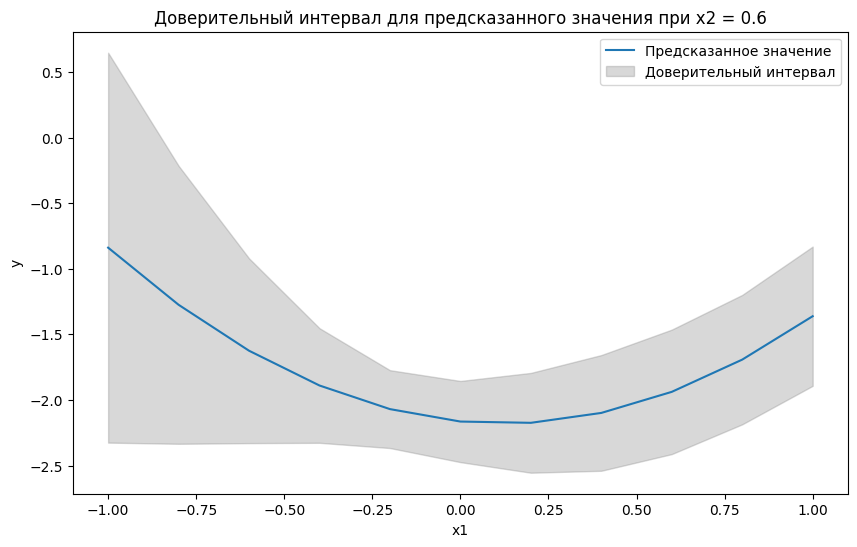

In [162]:
import matplotlib.pyplot as plt

# Точка для предсказания
x1_range = np.linspace(-1, 1, 11)
x2_fixed = 0.6

# Матрица регрессоров для предсказания
F_pred = np.array([
    np.ones_like(x1_range),
    x1_range,
    np.full_like(x1_range, x2_fixed),
    x1_range**2,
    x1_range * x2_fixed,
    np.full_like(x1_range, x2_fixed**2),
])
C = F_pred @ F_pred.T
# Предсказанные значения
y_pred = F_pred.T @ b

# Стандартная ошибка предсказания
se_pred = np.sqrt(np.diag(F_pred.T @ C @ F_pred) * s2)

# Доверительный интервал
ci_pred = np.column_stack([y_pred - t_kp * epsilon, y_pred + t_kp * epsilon])

# График
plt.figure(figsize=(10, 6))
plt.plot(x1_range, y_pred, label='Предсказанное значение')
plt.fill_between(x1_range, ci_pred[:, 0], ci_pred[:, 1], color='gray', alpha=0.3, label='Доверительный интервал')
plt.xlabel('x1')
plt.ylabel('y')
plt.title('Доверительный интервал для предсказанного значения при x2 = 0.6')
plt.legend()
plt.show()